In [1]:
!pip install --upgrade jinja2

Defaulting to user installation because normal site-packages is not writeable
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached MarkupSafe-2.1.5-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (3.0 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached MarkupSafe-2.1.5-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (26 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cookiecutter 2.6.0 requires rich, which is not installed.
spyder 4.1.5 requires pyqt5<5.13; python_version >= "3", which is not installed.
spyder 4.1.5 requires pyqtwebengine<5.13; python_version >= "3", which is not installed.


/home/yasir.ech-chammakhy/.local/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Base results directory: /home/yasir.ech-chammakhy/lustre/cyber_cc-lcbfvhtc9qm/users/yasir.ech-chammakhy/BEACON/outputs_beacon_coverage

Attempting to load individual results for models: ['bert-base-cased', 'roberta-base', 'ehsanaghaei/SecureBERT', 'markusbayer/CySecBERT', 's2w-ai/DarkBERT']
Checking for: /home/yasir.ech-chammakhy/lustre/cyber_cc-lcbfvhtc9qm/users/yasir.ech-chammakhy/BEACON/outputs_beacon_coverage/bert-base-cased_unified_coverage/final_evaluation_results.json
  --> Successfully loaded and processed results for 'bert-base-cased'.
Checking for: /home/yasir.ech-chammakhy/lustre/cyber_cc-lcbfvhtc9qm/users/yasir.ech-chammakhy/BEACON/outputs_beacon_coverage/roberta-base_unified_coverage/final_evaluation_results.json
  --> Successfully loaded and processed results for 'roberta-base'.
Checking for: /home/yasir.ech-chammakhy/lustre/cyber_cc-lcbfvhtc9qm/users/yasir.ech-chammakhy/BEACON/outputs_beacon_coverage/ehsanaghaei_SecureBERT_unified_coverage/final_evaluation_results.json
 

,Model,Best Valid F1,Overall Test F1,APTNER Test F1,CyNER Test F1,Attacker Test F1,DNRTI Test F1,Avg Pred Ent/Sent,Sent Recall (Micro),Sent Recall (Macro),Best Epoch
0,RoBERTa,0.728,0.736,0.699,0.813,0.660,0.813,2.437,0.721,0.725,31
1,SecureBERT,0.720,0.730,0.706,0.801,0.652,0.796,2.424,0.718,0.724,25
2,CySecBERT,0.717,0.728,0.697,0.784,0.662,0.797,2.470,0.718,0.717,16
3,DarkBERT,0.713,0.726,0.689,0.785,0.662,0.800,2.530,0.716,0.720,15
4,BERT-base,0.720,0.723,0.687,0.774,0.659,0.797,2.674,0.727,0.720,14



--- Generating Figure 1: Overall F1 Comparison on BEACON ---
Displaying Overall F1 comparison plot:


<ipython-input-2-b28aefcbef08>:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


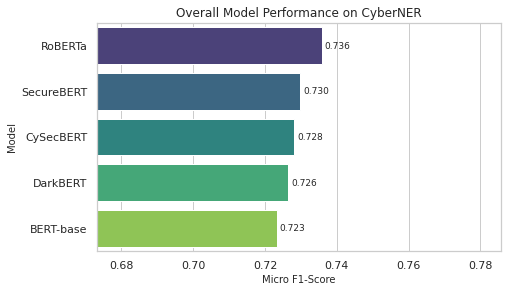


--- Generating Figure 2: Source-Specific F1 Comparison ---
Displaying Source-Specific F1 comparison plot:


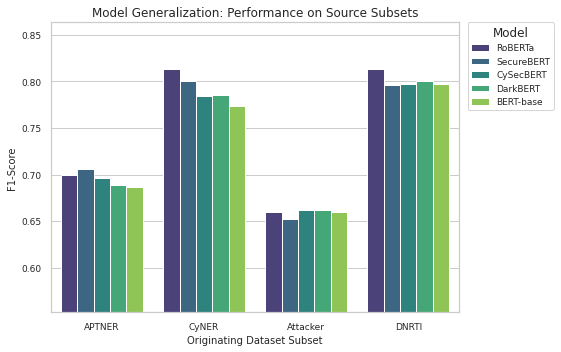


--- Displaying DataFrame: Key Coverage Metrics ---


,Model,Overall Test F1,Avg Pred Ent/Sent,Sent Recall (Micro),Sent Recall (Macro)
0,RoBERTa,0.736,2.44,72.1%,72.5%
1,SecureBERT,0.730,2.42,71.8%,72.4%
2,CySecBERT,0.728,2.47,71.8%,71.7%
3,DarkBERT,0.726,2.53,71.6%,72.0%
4,BERT-base,0.723,2.67,72.7%,72.0%



Notebook finished.
Final results figures and coverage metrics DataFrame displayed above.
Use these visuals and the DataFrame to populate the results section of your paper.


In [2]:
# -*- coding: utf-8 -*-
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: light
#       format_version: '1.5'
#       jupytext_version: 1.14.5 # Adjust if needed
#   kernelspec:
#     display_name: Python 3 (ipykernel)
#     language: python
#     name: python3
# ---

# # BEACON Final Results Visualization (Figures Focus)

# This notebook loads the final results from the individual model output directories
# (e.g., `roberta-base_unified_coverage/final_evaluation_results.json`) for ALL 
# completed models, including DarkBERT. 
# It prioritizes generating high-quality figures suitable for the paper and displays
# supporting DataFrames directly in the notebook output.
# **No figures or results files will be saved to disk.**

# ## 1. Setup

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Configuration ---
# *** IMPORTANT: SET THIS PATH CORRECTLY - It's the BASE directory containing model subdirs ***
BASE_OUTPUT_DIR = '/home/yasir.ech-chammakhy/lustre/cyber_cc-lcbfvhtc9qm/users/yasir.ech-chammakhy/BEACON/outputs_beacon_coverage' 

# *** IMPORTANT: List ALL models whose runs have COMPLETED and have a results file ***
# Should now include DarkBERT
COMPLETED_MODELS = [
    "bert-base-cased",
    "roberta-base",
    "ehsanaghaei/SecureBERT",
    "markusbayer/CySecBERT",
    "s2w-ai/DarkBERT" 
]

# Define source names for the source-specific plot/table
SOURCES_TO_EVALUATE = ['APTNER', 'CyNER', 'Attacker', 'DNRTI']

# Define shorter names for models (for tables/figures)
MODEL_NAME_MAP = {
    "bert-base-cased": "BERT-base",
    "roberta-base": "RoBERTa",
    "ehsanaghaei/SecureBERT": "SecureBERT",
    "markusbayer/CySecBERT": "CySecBERT",
    "s2w-ai/DarkBERT": "DarkBERT"
}

# Style settings for plots and DataFrames
sns.set_theme(style="whitegrid", palette="viridis") # Using 'viridis' palette
plt.rcParams['figure.dpi'] = 150 # Increase DPI for potentially higher quality inline display
plt.rcParams['figure.figsize'] = (8, 5) # Default figure size
plt.rcParams['font.size'] = 10 # Default font size
pd.set_option('display.precision', 3) 
pd.set_option('display.max_rows', 50)
pd.set_option('display.width', 120) 


# ## 2. Load and Process Final Results Data

print(f"Base results directory: {BASE_OUTPUT_DIR}")
if not os.path.isdir(BASE_OUTPUT_DIR):
    print(f"ERROR: Base output directory not found at '{BASE_OUTPUT_DIR}'. Please check the path.")
    raise FileNotFoundError(f"Base output directory not found: {BASE_OUTPUT_DIR}")

# --- Data Extraction (Looping through completed models) ---
processed_data = []
print(f"\nAttempting to load individual results for models: {COMPLETED_MODELS}")

for model_id in COMPLETED_MODELS:
    model_id_safe = model_id.replace('/', '_') 
    model_subdir_name = f"{model_id_safe}_unified_coverage"
    model_results_path = os.path.join(BASE_OUTPUT_DIR, model_subdir_name, 'final_evaluation_results.json')
    
    print(f"Checking for: {model_results_path}")
    
    if not os.path.exists(model_results_path):
        print(f"  --> WARNING: Results file not found for '{model_id}'. Skipping.")
        continue
        
    try:
        with open(model_results_path, 'r', encoding='utf-8') as f:
            results = json.load(f) 
        
        if not isinstance(results, dict): 
            print(f"  --> WARNING: Invalid content in results file for '{model_id}'. Skipping.")
            continue
            
        model_short_name = MODEL_NAME_MAP.get(model_id, model_id) 
        overall_f1 = results.get('overall_test_f1', np.nan)
        best_valid_f1 = results.get('best_valid_f1', np.nan)
        best_epoch = results.get('best_epoch', np.nan)

        source_f1s = {}
        source_results_dict = results.get('source_specific_test_results', {})
        for source in SOURCES_TO_EVALUATE:
            source_f1s[source] = source_results_dict.get(source, {}).get('f1', np.nan)
            
        coverage = results.get('overall_coverage_metrics', {})
        avg_pred_entities = coverage.get('avg_pred_entities_per_sentence', np.nan)
        sent_recall_micro = coverage.get('sentence_entity_recall_micro', np.nan)
        sent_recall_macro = coverage.get('sentence_entity_recall_macro', np.nan)
        
        processed_data.append({
            'Model': model_short_name,
            'Best Valid F1': best_valid_f1,
            'Overall Test F1': overall_f1,
            **{f'{src} Test F1': f1 for src, f1 in source_f1s.items()}, 
            'Avg Pred Ent/Sent': avg_pred_entities,
            'Sent Recall (Micro)': sent_recall_micro,
            'Sent Recall (Macro)': sent_recall_macro,
            'Best Epoch': best_epoch
        })
        print(f"  --> Successfully loaded and processed results for '{model_id}'.")

    except Exception as e:
        print(f"  --> ERROR processing results file for '{model_id}': {e}")

# Create DataFrame
if not processed_data:
     print("\nERROR: No data was successfully processed. Check the COMPLETED_MODELS list and individual results file paths/contents.")
     # Optional: raise ValueError("No results processed.") 
else:
    results_df = pd.DataFrame(processed_data)
    results_df = results_df.sort_values(by='Overall Test F1', ascending=False).reset_index(drop=True)
    print("\n--- Final Processed Results DataFrame ---")
    display(results_df) 

# ## 3. Generate Figures for Paper

# --- Figure 1: Overall Performance Comparison ---
print("\n--- Generating Figure 1: Overall F1 Comparison on BEACON ---")
if not results_df.empty and 'Overall Test F1' in results_df.columns:
    try:
        plt.figure(figsize=(7, 4)) # Adjusted size for potential paper column fit
        
        plot_df_overall = results_df.dropna(subset=['Overall Test F1']).sort_values(by='Overall Test F1', ascending=False)
        
        if not plot_df_overall.empty:
            ax = sns.barplot(
                x='Overall Test F1', 
                y='Model', 
                data=plot_df_overall, 
                palette='viridis' # Consistent palette
            )
            
            plt.title('Overall Model Performance on BEACON', fontsize=12) 
            plt.xlabel('Micro F1-Score', fontsize=10)
            plt.ylabel('Model', fontsize=10)
            
            # Adjust xlim based on actual data range for better visuals
            min_f1 = plot_df_overall['Overall Test F1'].min()
            max_f1 = plot_df_overall['Overall Test F1'].max()
            plt.xlim(left=max(0, min_f1 - 0.05), right=min(1, max_f1 + 0.05)) 

            # Add data labels
            for i in ax.containers:
                ax.bar_label(i, fmt='%.3f', padding=3, fontsize=9)
                
            plt.tight_layout(pad=0.5) # Add some padding
            
            print("Displaying Overall F1 comparison plot:") 
            plt.show() 
            plt.close()
        else:
            print("Skipping plot: No valid Overall F1 scores found.")

    except Exception as e:
        print(f"Could not generate Overall F1 plot: {e}")
else:
     print("Skipping Overall F1 Figure generation: No processed data or F1 column missing.")


# --- Figure 2: Source-Specific Performance Comparison ---
print("\n--- Generating Figure 2: Source-Specific F1 Comparison ---")
if not results_df.empty:
    try:
        source_f1_cols = [f'{src} Test F1' for src in SOURCES_TO_EVALUATE]
        if not all(col in results_df.columns for col in source_f1_cols):
             print("Skipping plot: Missing one or more source F1 columns.")
        else:
            # Melt the DataFrame for seaborn grouped bar plot
            melted_df = pd.melt(results_df, 
                                id_vars=['Model'], 
                                value_vars=source_f1_cols, 
                                var_name='Source Dataset', 
                                value_name='F1-Score')
            
            # Clean up source names for display
            melted_df['Source Dataset'] = melted_df['Source Dataset'].str.replace(' Test F1', '')
            
            plt.figure(figsize=(9, 5)) # Slightly wider for grouped bars
            
            ax = sns.barplot(
                x='Source Dataset', 
                y='F1-Score', 
                hue='Model', 
                data=melted_df.dropna(subset=['F1-Score']),
                palette='viridis' # Use same palette
            )
            
            plt.title('Model Generalization: Performance on Source Subsets', fontsize=12)
            plt.xlabel('Originating Dataset Subset', fontsize=10)
            plt.ylabel('F1-Score', fontsize=10)
            plt.ylim(bottom=max(0, melted_df['F1-Score'].min() - 0.1), top=min(1, melted_df['F1-Score'].max() + 0.05)) # Adjust ylim
            plt.xticks(rotation=0, ha='center', fontsize=9)
            plt.yticks(fontsize=9)
            
            # Improve legend placement
            plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., fontsize=9)
            
            plt.tight_layout(rect=[0, 0, 0.88, 1]) # Adjust layout to make space for legend outside
            
            print("Displaying Source-Specific F1 comparison plot:") 
            plt.show()
            plt.close()

    except Exception as e:
        print(f"Could not generate Source-Specific F1 plot: {e}")
else:
     print("Skipping Source-Specific F1 Figure generation: No processed data.")

# ## 4. Display Coverage Metrics DataFrame

# Coverage metrics are often best presented in a table alongside F1 for context.
print("\n--- Displaying DataFrame: Key Coverage Metrics ---")
if not results_df.empty:
    coverage_cols = ['Model', 'Overall Test F1', 'Avg Pred Ent/Sent', 'Sent Recall (Micro)', 'Sent Recall (Macro)']
    if all(col in results_df.columns for col in coverage_cols):
        # Select and format for display
        table_coverage_df = results_df[coverage_cols].copy()
        table_coverage_df = table_coverage_df.sort_values(by='Overall Test F1', ascending=False)
        
        # Apply formatting for better readability
        table_coverage_df['Sent Recall (Micro)'] = (table_coverage_df['Sent Recall (Micro)'] * 100)
        table_coverage_df['Sent Recall (Macro)'] = (table_coverage_df['Sent Recall (Macro)'] * 100)
        
        display(table_coverage_df.style.format({
            'Overall Test F1': "{:.3f}",
            'Avg Pred Ent/Sent': "{:.2f}",
            'Sent Recall (Micro)': "{:.1f}%",
            'Sent Recall (Macro)': "{:.1f}%"
        }))
    else:
         print("Skipping display: Missing one or more required columns for coverage table.")
else:
    print("Skipping Coverage Metrics display: No processed data.")


# ## 5. Conclusion

print("\nNotebook finished.")
print("Final results figures and coverage metrics DataFrame displayed above.")
print("Use these visuals and the DataFrame to populate the results section of your paper.")

Base results directory: /home/yasir.ech-chammakhy/lustre/cyber_cc-lcbfvhtc9qm/users/yasir.ech-chammakhy/BEACON/outputs_beacon_coverage

Attempting to load individual results for models: ['bert-base-cased', 'roberta-base', 'ehsanaghaei/SecureBERT', 'markusbayer/CySecBERT']
Checking for: /home/yasir.ech-chammakhy/lustre/cyber_cc-lcbfvhtc9qm/users/yasir.ech-chammakhy/BEACON/outputs_beacon_coverage/bert-base-cased_unified_coverage/final_evaluation_results.json
  --> Successfully loaded and processed results for 'bert-base-cased'.
Checking for: /home/yasir.ech-chammakhy/lustre/cyber_cc-lcbfvhtc9qm/users/yasir.ech-chammakhy/BEACON/outputs_beacon_coverage/roberta-base_unified_coverage/final_evaluation_results.json
  --> Successfully loaded and processed results for 'roberta-base'.
Checking for: /home/yasir.ech-chammakhy/lustre/cyber_cc-lcbfvhtc9qm/users/yasir.ech-chammakhy/BEACON/outputs_beacon_coverage/ehsanaghaei_SecureBERT_unified_coverage/final_evaluation_results.json
  --> Successfully l

,Model,Best Valid F1,Overall Test F1,APTNER Test F1,CyNER Test F1,Attacker Test F1,DNRTI Test F1,Avg Pred Ent/Sent,Sent Recall (Micro),Sent Recall (Macro),Best Epoch
0,RoBERTa,0.728,0.736,0.699,0.813,0.660,0.813,2.437,0.721,0.725,31
1,SecureBERT,0.720,0.730,0.706,0.801,0.652,0.796,2.424,0.718,0.724,25
2,CySecBERT,0.717,0.728,0.697,0.784,0.662,0.797,2.470,0.718,0.717,16
3,BERT-base,0.720,0.723,0.687,0.774,0.659,0.797,2.674,0.727,0.720,14



--- Displaying DataFrame 1: Overall Performance on BEACON (Based on available runs) ---


,Model,F1-Score
0,RoBERTa,0.736
1,SecureBERT,0.730
2,CySecBERT,0.728
3,BERT-base,0.723



--- Displaying DataFrame 2: Source-Specific Performance (Based on available runs) ---


,Model,APTNER Test F1,CyNER Test F1,Attacker Test F1,DNRTI Test F1,Average Source F1
0,RoBERTa,0.699,0.813,0.660,0.813,0.746
1,SecureBERT,0.706,0.801,0.652,0.796,0.739
2,CySecBERT,0.697,0.784,0.662,0.797,0.735
3,BERT-base,0.687,0.774,0.659,0.797,0.729



--- Displaying DataFrame 3: Coverage Metrics (Based on available runs) ---


,Model,Overall Test F1,Avg Pred Ent/Sent,Sent Recall (Micro),Sent Recall (Macro)
0,RoBERTa,0.736,2.437,0.721,0.725
1,SecureBERT,0.730,2.424,0.718,0.724
2,CySecBERT,0.728,2.470,0.718,0.717
3,BERT-base,0.723,2.674,0.727,0.720



--- Displaying Optional Figure: Overall F1 Comparison (Based on available runs) ---
Displaying overall F1 comparison plot (for available runs):


<ipython-input-9-3d736f1a1267>:196: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


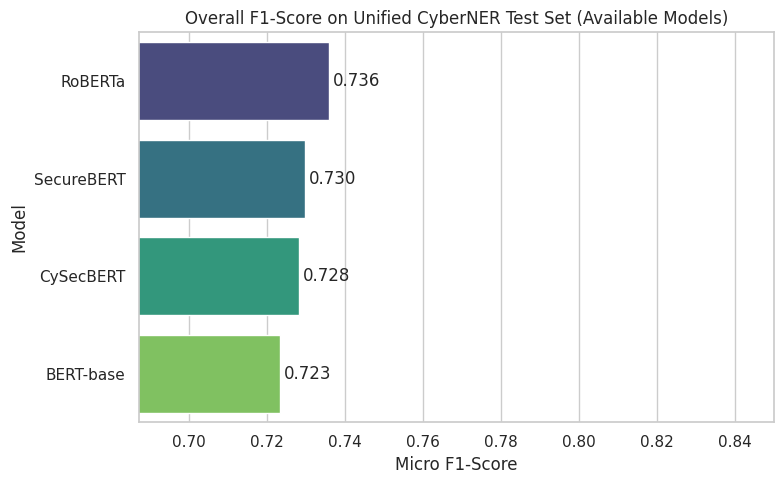


Notebook finished.
Results DataFrames (based on individually loaded results) are displayed above.
The optional figure (based on individually loaded results) was displayed above.

*** IMPORTANT: Ensure the COMPLETED_MODELS list is accurate. Re-run or modify the list once DarkBERT finishes to include its results. ***


In [9]:
# -*- coding: utf-8 -*-
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: light
#       format_version: '1.5'
#       jupytext_version: 1.14.5 # Adjust if needed
#   kernelspec:
#     display_name: Python 3 (ipykernel)
#     language: python
#     name: python3
# ---

# # BEACON Results Display (Loading Individual Files)

# This notebook loads results directly from individual model output directories
# (e.g., `roberta-base_unified_coverage/final_evaluation_results.json`) for models
# specified in `COMPLETED_MODELS`. It displays the results as pandas DataFrames
# and shows a comparison figure directly in the notebook.
# **No files will be saved.**

# ## 1. Setup

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Configuration ---
# *** IMPORTANT: SET THIS PATH CORRECTLY - It's the BASE directory containing model subdirs ***
BASE_OUTPUT_DIR = '/home/yasir.ech-chammakhy/lustre/cyber_cc-lcbfvhtc9qm/users/yasir.ech-chammakhy/BEACON/outputs_beacon_coverage' 

# *** IMPORTANT: List the models whose runs have COMPLETED and have a results file ***
# Exclude 's2w-ai/DarkBERT' for now if it's not finished
COMPLETED_MODELS = [
    "bert-base-cased",
    "roberta-base",
    "ehsanaghaei/SecureBERT",
    "markusbayer/CySecBERT"
    # Add "s2w-ai/DarkBERT" here once its run completes and the file exists
]

# Define source names for the source-specific table
SOURCES_TO_EVALUATE = ['APTNER', 'CyNER', 'Attacker', 'DNRTI']

# Define shorter names for models (for tables/figures)
MODEL_NAME_MAP = {
    "bert-base-cased": "BERT-base",
    "roberta-base": "RoBERTa",
    "ehsanaghaei/SecureBERT": "SecureBERT",
    "markusbayer/CySecBERT": "CySecBERT",
    "s2w-ai/DarkBERT": "DarkBERT"
    # Add other models if you trained more
}

# Style settings for plots and DataFrames
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100 
pd.set_option('display.precision', 3) # Format floats to 3 decimal places in DataFrame display
pd.set_option('display.max_rows', 50)
pd.set_option('display.width', 100) # Adjust display width


# ## 2. Load and Process Results Data from Individual Files

print(f"Base results directory: {BASE_OUTPUT_DIR}")
if not os.path.isdir(BASE_OUTPUT_DIR):
    print(f"ERROR: Base output directory not found at '{BASE_OUTPUT_DIR}'. Please check the path.")
    raise FileNotFoundError(f"Base output directory not found: {BASE_OUTPUT_DIR}")

# --- Data Extraction (Looping through completed models) ---
processed_data = []
print(f"\nAttempting to load individual results for models: {COMPLETED_MODELS}")

for model_id in COMPLETED_MODELS:
    # Construct the expected path to the model's results file
    model_id_safe = model_id.replace('/', '_') # Handle potential slashes in model names
    model_subdir_name = f"{model_id_safe}_unified_coverage"
    model_results_path = os.path.join(BASE_OUTPUT_DIR, model_subdir_name, 'final_evaluation_results.json')
    
    print(f"Checking for: {model_results_path}")
    
    if not os.path.exists(model_results_path):
        print(f"  --> WARNING: Results file not found for '{model_id}'. Skipping.")
        continue
        
    try:
        with open(model_results_path, 'r', encoding='utf-8') as f:
            results = json.load(f) # Load this specific model's results file
        
        if not isinstance(results, dict): 
            print(f"  --> WARNING: Invalid content in results file for '{model_id}'. Skipping.")
            continue
            
        # Extract the necessary data points using .get() for safety
        model_short_name = MODEL_NAME_MAP.get(model_id, model_id) 
        overall_f1 = results.get('overall_test_f1', np.nan)
        best_valid_f1 = results.get('best_valid_f1', np.nan)
        best_epoch = results.get('best_epoch', np.nan)

        # Extract source-specific performance
        source_f1s = {}
        source_results_dict = results.get('source_specific_test_results', {})
        for source in SOURCES_TO_EVALUATE:
            source_f1s[source] = source_results_dict.get(source, {}).get('f1', np.nan)
            
        # Extract key Coverage Metrics (from overall evaluation)
        coverage = results.get('overall_coverage_metrics', {})
        avg_pred_entities = coverage.get('avg_pred_entities_per_sentence', np.nan)
        sent_recall_micro = coverage.get('sentence_entity_recall_micro', np.nan)
        sent_recall_macro = coverage.get('sentence_entity_recall_macro', np.nan)
        
        processed_data.append({
            'Model': model_short_name,
            'Best Valid F1': best_valid_f1,
            'Overall Test F1': overall_f1,
            **{f'{src} Test F1': f1 for src, f1 in source_f1s.items()}, 
            'Avg Pred Ent/Sent': avg_pred_entities,
            'Sent Recall (Micro)': sent_recall_micro,
            'Sent Recall (Macro)': sent_recall_macro,
            'Best Epoch': best_epoch
        })
        print(f"  --> Successfully loaded and processed results for '{model_id}'.")

    except Exception as e:
        print(f"  --> ERROR processing results file for '{model_id}': {e}")

# Create DataFrame
if not processed_data:
     print("\nERROR: No data was successfully processed. Check the COMPLETED_MODELS list and individual results file paths/contents.")
     # Optional: raise ValueError("No results processed.") 
else:
    results_df = pd.DataFrame(processed_data)
    results_df = results_df.sort_values(by='Overall Test F1', ascending=False).reset_index(drop=True)
    print("\nProcessed Results DataFrame (Loaded from individual files):")
    # Display the full dataframe directly
    display(results_df) 

# ## 3. Display Results as DataFrames

# --- DataFrame 1: Overall Performance on BEACON ---
print("\n--- Displaying DataFrame 1: Overall Performance on BEACON (Based on available runs) ---")
if not results_df.empty:
    table1_df = results_df[['Model', 'Overall Test F1']].copy()
    table1_df.rename(columns={'Overall Test F1': 'F1-Score'}, inplace=True)
    # Display the dataframe
    display(table1_df) 
else:
    print("Skipping DataFrame 1 display: No processed data.")

# --- DataFrame 2: Source-Specific Performance of Unified Models ---
print("\n--- Displaying DataFrame 2: Source-Specific Performance (Based on available runs) ---")
if not results_df.empty:
    source_cols = [f'{src} Test F1' for src in SOURCES_TO_EVALUATE]
    table2_df = results_df[['Model'] + source_cols].copy()
    
    # Add an average column 
    table2_df['Average Source F1'] = table2_df[source_cols].mean(axis=1)
    table2_df = table2_df.sort_values(by='Average Source F1', ascending=False)

    # Display the dataframe
    display(table2_df) 
else:
    print("Skipping DataFrame 2 display: No processed data.")

# --- DataFrame 3: Key Coverage Metrics ---
print("\n--- Displaying DataFrame 3: Coverage Metrics (Based on available runs) ---")
if not results_df.empty:
    table3_df = results_df[['Model', 'Overall Test F1', 'Avg Pred Ent/Sent', 'Sent Recall (Micro)', 'Sent Recall (Macro)']].copy()
    table3_df = table3_df.sort_values(by='Overall Test F1', ascending=False)

    # Optional: Format recall as percentage *string* for display if needed, but numerical is often better
    # table3_df['Sent Recall (Micro)'] = (table3_df['Sent Recall (Micro)'] * 100).map('{:.1f}%'.format)
    # table3_df['Sent Recall (Macro)'] = (table3_df['Sent Recall (Macro)'] * 100).map('{:.1f}%'.format)

    # Display the dataframe
    display(table3_df) 
else:
    print("Skipping DataFrame 3 display: No processed data.")


# ## 4. Optional: Display Figure

print("\n--- Displaying Optional Figure: Overall F1 Comparison (Based on available runs) ---")
if not results_df.empty and 'Overall Test F1' in results_df.columns:
    try:
        plt.figure(figsize=(8, 5)) 
        
        plot_df = results_df.dropna(subset=['Overall Test F1']).sort_values(by='Overall Test F1', ascending=False)
        
        if not plot_df.empty:
            ax = sns.barplot(
                x='Overall Test F1', 
                y='Model', 
                data=plot_df, 
                palette='viridis' 
            )
            
            plt.title('Overall F1-Score on Unified BEACON Test Set (Available Models)') # Adjusted title
            plt.xlabel('Micro F1-Score')
            plt.ylabel('Model')
            plt.xlim(left=min(0.7, plot_df['Overall Test F1'].min() * 0.95 if not plot_df.empty else 0.7), 
                     right=max(0.85, plot_df['Overall Test F1'].max() * 1.02 if not plot_df.empty else 0.85)) 

            for i in ax.containers:
                ax.bar_label(i, fmt='%.3f', padding=3)
                
            plt.tight_layout()
            
            print(f"Displaying overall F1 comparison plot (for available runs):") 
            plt.show() # Display in notebook
            plt.close() # Close the plot figure object
        else:
            print("Skipping plot: No valid F1 scores found after dropping NaNs.")

    except Exception as e:
        print(f"Could not generate plot: {e}")
else:
     print("Skipping Figure generation: No processed data or F1 column missing.")


# ## 5. Conclusion and Next Steps

print("\nNotebook finished.")
print("Results DataFrames (based on individually loaded results) are displayed above.")
print("The optional figure (based on individually loaded results) was displayed above.")
print("\n*** IMPORTANT: Ensure the COMPLETED_MODELS list is accurate. Re-run or modify the list once DarkBERT finishes to include its results. ***")

In [7]:
# -*- coding: utf-8 -*-
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: light
#       format_version: '1.5'
#       jupytext_version: 1.14.5 # Adjust if needed
#   kernelspec:
#     display_name: Python 3 (ipykernel)
#     language: python
#     name: python3
# ---

# # BEACON Results Visualization (Partial - Excluding DarkBERT)

# This notebook loads the aggregated results (`all_models_summary_results_coverage.json`) 
# and generates concise tables and optionally a figure suitable for a 6-page paper.
# It focuses on presenting the most impactful findings regarding model performance
# on the unified BEACON dataset.
# **Crucially, it currently processes only the models specified in the `COMPLETED_MODELS` list.**
# **No figures or results files will be saved.**

# ## 1. Setup

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Configuration ---
# *** IMPORTANT: SET THIS PATH CORRECTLY ***
RESULTS_FILE_PATH = '/home/yasir.ech-chammakhy/lustre/cyber_cc-lcbfvhtc9qm/users/yasir.ech-chammakhy/BEACON/outputs_beacon_coverage/all_models_summary_results_coverage.json' 

# *** IMPORTANT: List the models whose results are COMPLETE in the JSON file ***
# Exclude 's2w-ai/DarkBERT' for now
COMPLETED_MODELS = [
    "bert-base-cased",
    "roberta-base",
    "ehsanaghaei/SecureBERT",
    "markusbayer/CySecBERT"
    # Add "s2w-ai/DarkBERT" here once its results are in the JSON file
]

# Define source names for the source-specific table
SOURCES_TO_EVALUATE = ['APTNER', 'CyNER', 'Attacker', 'DNRTI']

# Define shorter names for models (for tables/figures)
MODEL_NAME_MAP = {
    "bert-base-cased": "BERT-base",
    "roberta-base": "RoBERTa",
    "ehsanaghaei/SecureBERT": "SecureBERT",
    "markusbayer/CySecBERT": "CySecBERT",
    "s2w-ai/DarkBERT": "DarkBERT"
    # Add other models if you trained more
}

# Style settings for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100 # Adjust for notebook display resolution if needed


# ## 2. Load and Process Results Data

print(f"Loading results from: {RESULTS_FILE_PATH}")

if not os.path.exists(RESULTS_FILE_PATH):
    print(f"ERROR: Results file not found at '{RESULTS_FILE_PATH}'. Please check the path.")
    # Stop execution if file not found in a notebook environment
    raise FileNotFoundError(f"Results file not found: {RESULTS_FILE_PATH}")
else:
    try:
        with open(RESULTS_FILE_PATH, 'r', encoding='utf-8') as f:
            all_results = json.load(f)
        print(f"Successfully loaded results JSON containing data for {len(all_results)} model runs.")
    except Exception as e:
        print(f"Error loading or parsing JSON file: {e}")
        raise

# --- Data Extraction (Filtering for Completed Models) ---
processed_data = []
print(f"\nProcessing results ONLY for completed models: {COMPLETED_MODELS}")
for model_id in COMPLETED_MODELS:
    if model_id not in all_results:
        print(f"Warning: Results for model '{model_id}' not found in the JSON file. Skipping.")
        continue
        
    results = all_results[model_id]
    
    if not isinstance(results, dict): # Skip if results entry isn't a dictionary
        print(f"Warning: Skipping invalid result entry for model '{model_id}'")
        continue
        
    model_short_name = MODEL_NAME_MAP.get(model_id, model_id) # Get short name or use original ID
    
    # Overall performance
    overall_f1 = results.get('overall_test_f1', np.nan)
    best_valid_f1 = results.get('best_valid_f1', np.nan)
    best_epoch = results.get('best_epoch', np.nan)

    # Source-specific performance
    source_f1s = {}
    source_results = results.get('source_specific_test_results', {})
    for source in SOURCES_TO_EVALUATE:
        source_f1s[source] = source_results.get(source, {}).get('f1', np.nan)
        
    # Key Coverage Metrics (from overall evaluation)
    coverage = results.get('overall_coverage_metrics', {})
    avg_pred_entities = coverage.get('avg_pred_entities_per_sentence', np.nan)
    sent_recall_micro = coverage.get('sentence_entity_recall_micro', np.nan)
    sent_recall_macro = coverage.get('sentence_entity_recall_macro', np.nan)
    
    processed_data.append({
        'Model': model_short_name,
        'Best Valid F1': best_valid_f1,
        'Overall Test F1': overall_f1,
        **{f'{src} Test F1': f1 for src, f1 in source_f1s.items()}, # Add source F1s directly
        'Avg Pred Ent/Sent': avg_pred_entities,
        'Sent Recall (Micro)': sent_recall_micro,
        'Sent Recall (Macro)': sent_recall_macro,
        'Best Epoch': best_epoch
    })

# Create DataFrame
if not processed_data:
     print("\nERROR: No data was processed. Check the COMPLETED_MODELS list and the JSON file content.")
     raise ValueError("No results processed for the specified completed models.")
else:
    results_df = pd.DataFrame(processed_data)
    results_df = results_df.sort_values(by='Overall Test F1', ascending=False).reset_index(drop=True)
    print("\nProcessed Results DataFrame (Excluding Incomplete Runs):")
    print(results_df.to_string()) # Display full dataframe in notebook

# ## 3. Generate Tables for Paper (Using Partial Results)

# --- Table 1: Overall Performance on BEACON ---
print("\n--- Generating Table 1: Overall Performance on BEACON (Partial Results) ---")
if not results_df.empty:
    table1_df = results_df[['Model', 'Overall Test F1']].copy()
    table1_df.rename(columns={'Overall Test F1': 'F1-Score'}, inplace=True)

    # Generate LaTeX code 
    latex_table1 = table1_df.to_latex(
        index=False, 
        float_format="%.3f", 
        caption="Overall Performance (Micro F1-Score) of different models trained and evaluated on the unified BEACON test set (Preliminary Results).", # Added note
        label="tab:overall_beacon_perf",
        booktabs=True,
        position='htbp' 
    )

    print("\nLaTeX Code for Table 1:")
    print(latex_table1)
else:
    print("Skipping Table 1 generation: No processed data.")

# --- Table 2: Source-Specific Performance of Unified Models ---
print("\n--- Generating Table 2: Source-Specific Performance (Partial Results) ---")
if not results_df.empty:
    source_cols = [f'{src} Test F1' for src in SOURCES_TO_EVALUATE]
    table2_df = results_df[['Model'] + source_cols].copy()
    
    # Add an average column 
    table2_df['Average Source F1'] = table2_df[source_cols].mean(axis=1)
    table2_df = table2_df.sort_values(by='Average Source F1', ascending=False)

    # Generate LaTeX code 
    latex_table2 = table2_df.to_latex(
        index=False, 
        float_format="%.3f", 
        caption="Source-Specific Performance (F1-Score) on test subsets, using models trained on the unified BEACON corpus (Preliminary Results).", # Added note
        label="tab:source_specific_perf",
        booktabs=True,
        position='htbp' 
    )

    print("\nLaTeX Code for Table 2:")
    print(latex_table2)
else:
    print("Skipping Table 2 generation: No processed data.")


# --- Table 3: Key Coverage Metrics ---
print("\n--- Generating Table 3: Coverage Metrics (Partial Results) ---")
if not results_df.empty:
    table3_df = results_df[['Model', 'Overall Test F1', 'Avg Pred Ent/Sent', 'Sent Recall (Micro)', 'Sent Recall (Macro)']].copy()
    table3_df = table3_df.sort_values(by='Overall Test F1', ascending=False)

    # Adjust formatting for recall (percentage)
    table3_df['Sent Recall (Micro)'] = table3_df['Sent Recall (Micro)'] * 100
    table3_df['Sent Recall (Macro)'] = table3_df['Sent Recall (Macro)'] * 100

    # Generate LaTeX code 
    latex_table3 = table3_df.to_latex(
        index=False, 
        formatters={
            'Overall Test F1': "{:.3f}".format,
            'Avg Pred Ent/Sent': "{:.2f}".format, 
            'Sent Recall (Micro)': "{:.1f}\%".format, 
            'Sent Recall (Macro)': "{:.1f}\%".format, 
        },
        escape=False, 
        caption="Key Evaluation Metrics, including sentence-level coverage, for models trained on BEACON (Preliminary Results).", # Added note
        label="tab:coverage_metrics",
        booktabs=True,
        position='htbp' 
    )

    print("\nLaTeX Code for Table 3:")
    print(latex_table3)
else:
    print("Skipping Table 3 generation: No processed data.")


# ## 4. Optional: Generate Figure for Paper (Using Partial Results)

print("\n--- Generating Optional Figure: Overall F1 Comparison (Partial Results) ---")
if not results_df.empty:
    try:
        plt.figure(figsize=(8, 5)) 
        
        plot_df = results_df.sort_values(by='Overall Test F1', ascending=False)
        
        ax = sns.barplot(
            x='Overall Test F1', 
            y='Model', 
            data=plot_df, 
            palette='viridis' 
        )
        
        plt.title('Overall F1-Score on Unified BEACON Test Set (Preliminary)') # Added note
        plt.xlabel('Micro F1-Score')
        plt.ylabel('Model')
        plt.xlim(left=min(0.7, plot_df['Overall Test F1'].min() * 0.95), right=max(0.85, plot_df['Overall Test F1'].max() * 1.02)) # Adjusted limits slightly

        for i in ax.containers:
            ax.bar_label(i, fmt='%.3f', padding=3)
            
        plt.tight_layout()
        
        print(f"Displaying overall F1 comparison plot (excluding incomplete runs):") 
        
        plt.show() # Display in notebook
        plt.close() # Close the plot figure object

    except Exception as e:
        print(f"Could not generate plot: {e}")
else:
     print("Skipping Figure generation: No processed data.")


# ## 5. Conclusion and Next Steps

print("\nNotebook finished.")
print("LaTeX code for tables (based on available results) is printed above.")
print("Remember to include \\usepackage{booktabs} in your LaTeX preamble.")
print("The optional figure (based on available results) was displayed above.")
print("\n*** IMPORTANT: Re-run this notebook after DarkBERT finishes and its results are included in the JSON file to get the complete tables and figure for your paper. ***")

Loading results from: /home/yasir.ech-chammakhy/lustre/cyber_cc-lcbfvhtc9qm/users/yasir.ech-chammakhy/BEACON/outputs_beacon_coverage/all_models_summary_results_coverage.json
ERROR: Results file not found at '/home/yasir.ech-chammakhy/lustre/cyber_cc-lcbfvhtc9qm/users/yasir.ech-chammakhy/BEACON/outputs_beacon_coverage/all_models_summary_results_coverage.json'. Please check the path.


FileNotFoundError: Results file not found: /home/yasir.ech-chammakhy/lustre/cyber_cc-lcbfvhtc9qm/users/yasir.ech-chammakhy/BEACON/outputs_beacon_coverage/all_models_summary_results_coverage.json

Loading aggregated results from /home/yasir.ech-chammakhy/lustre/cyber_cc-lcbfvhtc9qm/users/yasir.ech-chammakhy/BEACON/outputs_beacon/all_models_summary_results.json

Models with loaded results:
- bert-base-cased
- roberta-base
- ehsanaghaei/SecureBERT
- markusbayer/CySecBERT
- s2w-ai/DarkBERT

== Overall Model Performance Comparison ==


,model,overall_f1,best_valid_f1,APTNER_f1,CyNER_f1,Attacker_f1,DNRTI_f1
0,roberta-base,0.723768,0.711219,0.709977,0.799834,0.610316,0.806318
1,s2w-ai/DarkBERT,0.723008,0.709945,0.691190,0.774908,0.640457,0.807863
2,markusbayer/CySecBERT,0.722440,0.716342,0.698534,0.792875,0.616683,0.809655
3,bert-base-cased,0.714691,0.702775,0.698955,0.790582,0.605018,0.796422
4,ehsanaghaei/SecureBERT,0.708894,0.702060,0.714598,0.713397,0.618959,0.768053


,model,overall_f1,best_valid_f1,APTNER_f1,CyNER_f1,Attacker_f1,DNRTI_f1
0,roberta-base,72.38%,71.12%,71.00%,79.98%,61.03%,80.63%
1,s2w-ai/DarkBERT,72.30%,70.99%,69.12%,77.49%,64.05%,80.79%
2,markusbayer/CySecBERT,72.24%,71.63%,69.85%,79.29%,61.67%,80.97%
3,bert-base-cased,71.47%,70.28%,69.90%,79.06%,60.50%,79.64%
4,ehsanaghaei/SecureBERT,70.89%,70.21%,71.46%,71.34%,61.90%,76.81%


<ipython-input-5-8ad538300e8e>:152: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(x='model', y='overall_f1', data=performance_df, palette='viridis')


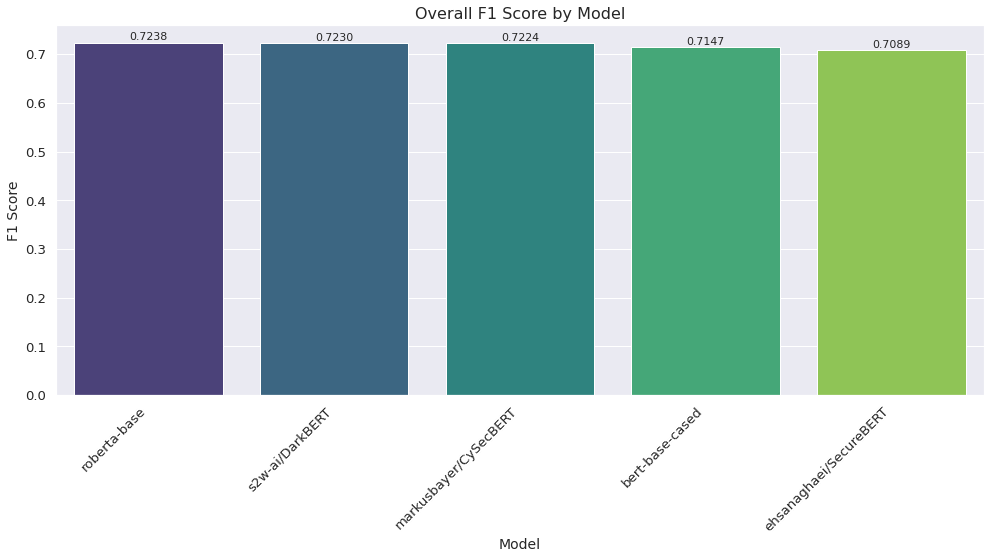

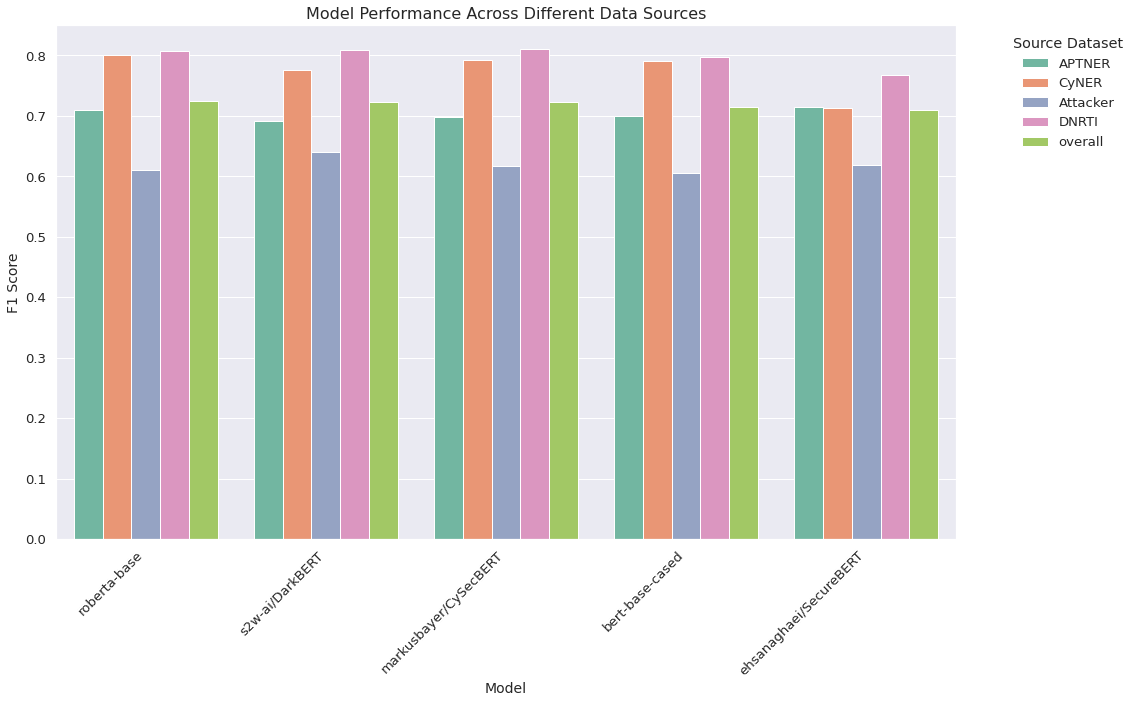

Detailed per-class analysis for best model: roberta-base


,class,precision,recall,f1,support
6,B-IPv4-Addr,0.884615,1.000000,0.938776,23
29,I-Location,0.892508,0.901316,0.896890,304
11,B-Location,0.880682,0.900116,0.890293,861
8,B-Indicator,0.925000,0.819188,0.868885,271
7,B-Identity,0.813264,0.888183,0.849074,1574
17,B-Threat-Actor,0.814892,0.883107,0.847629,1326
3,B-Domain-Name,0.806452,0.892857,0.847458,56
20,B-Vulnerability,0.842239,0.767981,0.803398,431
35,I-Threat-Actor,0.740826,0.875339,0.802484,369
4,B-Email-Addr,0.666667,1.000000,0.800000,4


,class,precision,recall,f1,support
6,B-IPv4-Addr,88.46%,100.00%,93.88%,23
29,I-Location,89.25%,90.13%,89.69%,304
11,B-Location,88.07%,90.01%,89.03%,861
8,B-Indicator,92.50%,81.92%,86.89%,271
7,B-Identity,81.33%,88.82%,84.91%,1574
17,B-Threat-Actor,81.49%,88.31%,84.76%,1326
3,B-Domain-Name,80.65%,89.29%,84.75%,56
20,B-Vulnerability,84.22%,76.80%,80.34%,431
35,I-Threat-Actor,74.08%,87.53%,80.25%,369
4,B-Email-Addr,66.67%,100.00%,80.00%,4


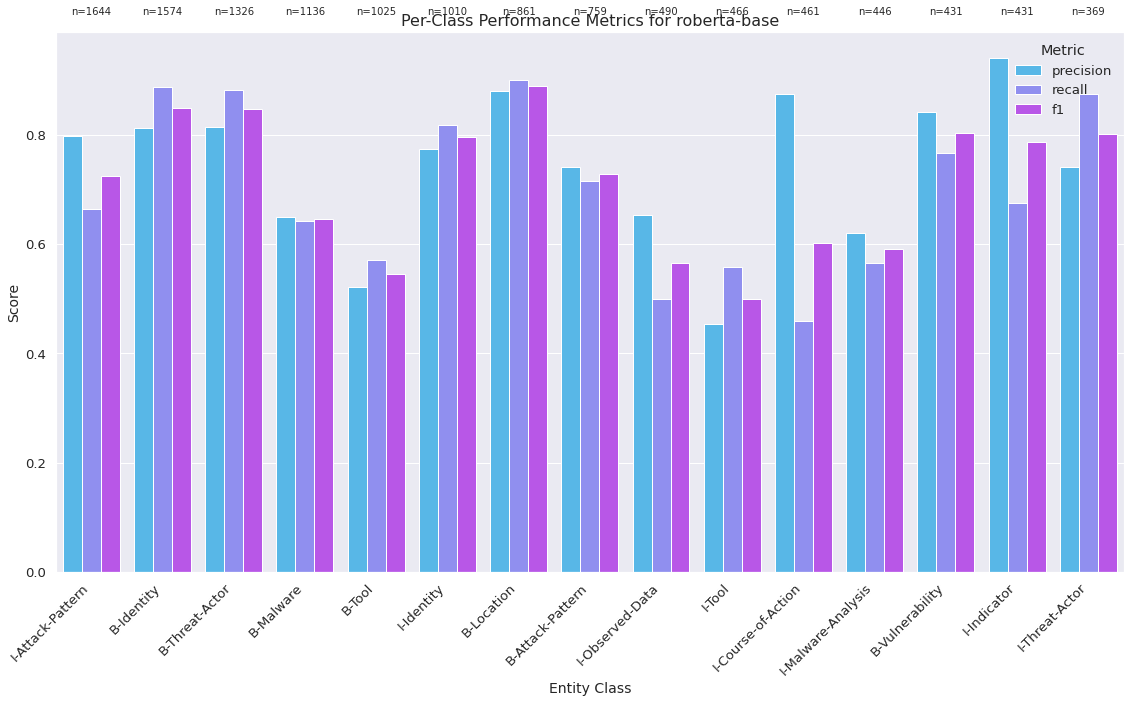

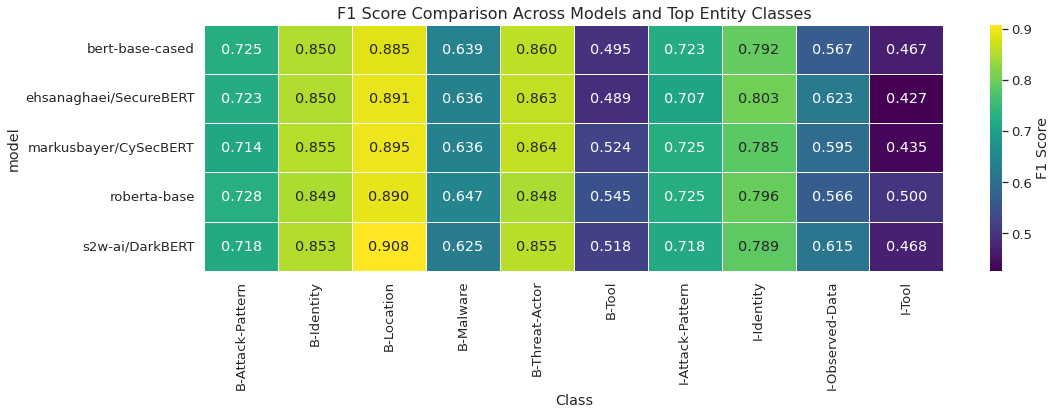

AttributeError: 'DataFrame' object has no attribute 'append'

In [5]:
# -*- coding: utf-8 -*-
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: light
#       format_version: '1.5'
#       jupytext_version: 1.14.5
#   kernelspec:
#     display_name: Python 3 (ipykernel)
#     language: python
#     name: python3
# ---

# # BEACON Model Performance Analysis
# 
# This notebook analyzes the results of various BERT-based models trained on the unified cybersecurity NER dataset.

# ## 1. Setup and Imports

import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display, HTML

# Set some plotting parameters
plt.style.use('ggplot')
sns.set(font_scale=1.2)
plt.rcParams["figure.figsize"] = (12, 8)

# ## 2. Load Results from All Models

# Specify the base output directory where all model results are stored
BASE_OUTPUT_DIR = '/home/yasir.ech-chammakhy/lustre/cyber_cc-lcbfvhtc9qm/users/yasir.ech-chammakhy/BEACON/outputs_beacon'

# Function to load results from individual model directories or from the summary file
def load_model_results():
    """
    Load results from either:
    1. The aggregated summary file (preferred)
    2. Individual model result files if the summary doesn't exist
    """
    summary_file = os.path.join(BASE_OUTPUT_DIR, 'all_models_summary_results.json')
    
    # Check if the aggregate summary file exists
    if os.path.exists(summary_file):
        print(f"Loading aggregated results from {summary_file}")
        with open(summary_file, 'r') as f:
            return json.load(f)
    
    # If summary doesn't exist, load individual files
    print("Aggregated summary not found. Loading from individual model directories...")
    results = {}
    
    # Get all subdirectories in the base output directory
    model_dirs = [d for d in os.listdir(BASE_OUTPUT_DIR) 
                 if os.path.isdir(os.path.join(BASE_OUTPUT_DIR, d))]
    
    for model_dir in model_dirs:
        results_file = os.path.join(BASE_OUTPUT_DIR, model_dir, 'final_evaluation_results.json')
        if os.path.exists(results_file):
            try:
                with open(results_file, 'r') as f:
                    model_results = json.load(f)
                    model_name = model_results.get('model_type', model_dir)
                    results[model_name] = model_results
                    print(f"Loaded results for {model_name}")
            except Exception as e:
                print(f"Error loading results from {results_file}: {e}")
    
    return results

# Load all model results
all_results = load_model_results()

# Check which models we have results for
print("\nModels with loaded results:")
for model_name in all_results.keys():
    print(f"- {model_name}")

# ## 3. Create Comparative Performance DataFrame

def create_performance_df(results):
    """
    Create a DataFrame with performance metrics for all models
    """
    performance_data = []
    
    for model_name, model_result in results.items():
        # Get overall test F1 score
        overall_f1 = model_result.get('overall_test_f1', 0.0)
        
        # Get best validation F1 score
        best_valid_f1 = model_result.get('best_valid_f1', 0.0)
        
        # Extract the source-specific F1 scores
        source_specific = model_result.get('source_specific_test_results', {})
        source_scores = {}
        
        for source, source_data in source_specific.items():
            source_scores[f"{source}_f1"] = source_data.get('f1', 0.0)
        
        # Combine all data
        model_data = {
            'model': model_name,
            'overall_f1': overall_f1,
            'best_valid_f1': best_valid_f1,
            **source_scores  # Unpack the source-specific scores
        }
        
        performance_data.append(model_data)
    
    # Create DataFrame and sort by overall F1 score
    df = pd.DataFrame(performance_data)
    if not df.empty and 'overall_f1' in df.columns:
        df = df.sort_values('overall_f1', ascending=False).reset_index(drop=True)
    
    return df

# Create the performance comparison DataFrame
performance_df = create_performance_df(all_results)

# Display the performance comparison
print("\n== Overall Model Performance Comparison ==")
display(performance_df)

# Format the DataFrames for better display with percentages
def format_percentage_df(df):
    """Format a DataFrame with F1 scores as percentages"""
    formatted_df = df.copy()
    # Identify columns with F1 scores (those containing 'f1' in the name)
    f1_columns = [col for col in formatted_df.columns if 'f1' in col.lower()]
    
    # Format these columns as percentages
    for col in f1_columns:
        formatted_df[col] = formatted_df[col].apply(lambda x: f"{x*100:.2f}%")
    
    return formatted_df

# Display with formatted percentages
display(HTML(format_percentage_df(performance_df).to_html()))

# ## 4. Visualize Overall Performance

# Bar chart of overall F1 scores
plt.figure(figsize=(14, 8))
chart = sns.barplot(x='model', y='overall_f1', data=performance_df, palette='viridis')
plt.title('Overall F1 Score by Model', fontsize=16)
plt.xlabel('Model', fontsize=14)
plt.ylabel('F1 Score', fontsize=14)
plt.xticks(rotation=45, ha='right')

# Add value labels on top of bars
for i, bar in enumerate(chart.patches):
    chart.text(
        bar.get_x() + bar.get_width()/2., 
        bar.get_height() + 0.005, 
        f'{bar.get_height():.4f}', 
        ha='center', fontsize=11
    )

plt.tight_layout()
plt.show()

# ## 5. Compare Performance Across Different Sources

# Extract source-specific columns for visualization
source_columns = [col for col in performance_df.columns if col.endswith('_f1') and col != 'overall_f1' and col != 'best_valid_f1']

if source_columns:
    # Reshape data for better visualization with seaborn
    plot_data = performance_df.melt(
        id_vars=['model'],
        value_vars=source_columns + ['overall_f1'],
        var_name='Source Dataset',
        value_name='F1 Score'
    )
    
    # Clean up source names for display
    plot_data['Source Dataset'] = plot_data['Source Dataset'].str.replace('_f1', '')
    
    # Plot performance across sources
    plt.figure(figsize=(16, 10))
    chart = sns.barplot(x='model', y='F1 Score', hue='Source Dataset', data=plot_data, palette='Set2')
    plt.title('Model Performance Across Different Data Sources', fontsize=16)
    plt.xlabel('Model', fontsize=14)
    plt.ylabel('F1 Score', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Source Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# ## 6. Detailed Per-Class Analysis

# Function to extract per-class metrics for a specific model
def get_class_metrics(model_name):
    """Extract per-class precision, recall, F1 and support for a model"""
    model_results = all_results.get(model_name, {})
    class_metrics = model_results.get('overall_class_metrics', {})
    
    # Create a DataFrame from the class metrics
    class_data = []
    
    for class_name, metrics in class_metrics.items():
        if class_name in ['O', 'X', '[CLS]', '[SEP]']:  # Skip special tokens
            continue
            
        class_data.append({
            'class': class_name,
            'precision': metrics.get('precision', 0.0),
            'recall': metrics.get('recall', 0.0),
            'f1': metrics.get('f1', 0.0),
            'support': metrics.get('support', 0)
        })
    
    df = pd.DataFrame(class_data)
    if not df.empty:
        df = df.sort_values('f1', ascending=False)
    
    return df

# Get the best performing model to analyze in detail
if not performance_df.empty and 'model' in performance_df.columns:
    best_model = performance_df.iloc[0]['model']
    print(f"Detailed per-class analysis for best model: {best_model}")
    
    best_model_class_df = get_class_metrics(best_model)
    if not best_model_class_df.empty:
        # Display the class metrics
        display(best_model_class_df)
        
        # Format and display as percentages for better readability
        formatted_class_df = best_model_class_df.copy()
        for col in ['precision', 'recall', 'f1']:
            formatted_class_df[col] = formatted_class_df[col].apply(lambda x: f"{x*100:.2f}%")
        display(HTML(formatted_class_df.to_html()))
        
        # Visualize per-class performance
        plt.figure(figsize=(16, 10))
        
        # Filter to top N classes by support for readability if there are many classes
        top_n = min(15, len(best_model_class_df))
        plot_df = best_model_class_df.nlargest(top_n, 'support')
        
        # Melt the DataFrame for easier plotting
        plot_data = plot_df.melt(
            id_vars=['class', 'support'],
            value_vars=['precision', 'recall', 'f1'],
            var_name='Metric',
            value_name='Score'
        )
        
        # Create a grouped bar chart
        chart = sns.barplot(
            x='class', y='Score', hue='Metric', 
            data=plot_data, palette='cool'
        )
        
        # Add support as text above bars
        for i, cls in enumerate(plot_df['class']):
            support = plot_df[plot_df['class'] == cls]['support'].values[0]
            plt.text(i, 1.02, f"n={support}", ha='center', fontsize=10)
        
        plt.title(f'Per-Class Performance Metrics for {best_model}', fontsize=16)
        plt.xlabel('Entity Class', fontsize=14)
        plt.ylabel('Score', fontsize=14)
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Metric')
        plt.tight_layout()
        plt.show()

# ## 7. Compare Per-Class Performance Across Models

# Function to extract F1 scores for all entity classes across all models
def compare_class_performance_across_models():
    """
    Create a DataFrame comparing F1 scores for each entity class across different models
    """
    # Get all unique entity classes from all models
    all_classes = set()
    for model_result in all_results.values():
        class_metrics = model_result.get('overall_class_metrics', {})
        all_classes.update(class_metrics.keys())
    
    # Remove special tokens
    all_classes = {cls for cls in all_classes if cls not in ['O', 'X', '[CLS]', '[SEP]']}
    
    # Create a comparison DataFrame
    comparison_data = []
    
    for model_name, model_result in all_results.items():
        class_metrics = model_result.get('overall_class_metrics', {})
        
        model_data = {'model': model_name}
        for cls in all_classes:
            if cls in class_metrics:
                model_data[f"{cls}_f1"] = class_metrics[cls].get('f1', 0.0)
                model_data[f"{cls}_support"] = class_metrics[cls].get('support', 0)
            else:
                model_data[f"{cls}_f1"] = 0.0
                model_data[f"{cls}_support"] = 0
        
        comparison_data.append(model_data)
    
    df = pd.DataFrame(comparison_data)
    
    # Sort by overall F1 score if available
    if 'overall_f1' in performance_df.columns:
        model_order = performance_df['model'].tolist()
        df['model_order'] = df['model'].apply(lambda x: model_order.index(x) if x in model_order else 999)
        df = df.sort_values('model_order').drop('model_order', axis=1)
    
    return df, all_classes

# Create the comparison DataFrame
class_comparison_df, unique_classes = compare_class_performance_across_models()

# Get a subset of important classes with significant support across models
important_classes = []
for cls in unique_classes:
    support_cols = [col for col in class_comparison_df.columns if col == f"{cls}_support"]
    if support_cols:
        avg_support = class_comparison_df[support_cols[0]].mean()
        if avg_support >= 10:  # Only include classes with reasonable support
            important_classes.append(cls)

# Sort by average support
important_classes.sort(key=lambda cls: class_comparison_df[f"{cls}_support"].mean(), reverse=True)

# Limit to top N classes for readability
top_n_classes = min(10, len(important_classes))
selected_classes = important_classes[:top_n_classes]

# Select only the F1 columns for the selected classes
selected_columns = ['model'] + [f"{cls}_f1" for cls in selected_classes]
selected_df = class_comparison_df[selected_columns]

# Reshape for plotting
plot_data = selected_df.melt(
    id_vars=['model'], 
    value_vars=[f"{cls}_f1" for cls in selected_classes],
    var_name='Class',
    value_name='F1 Score'
)

# Clean up class names
plot_data['Class'] = plot_data['Class'].str.replace('_f1', '')

# Create heatmap for comparing model performance on top classes
pivot_data = plot_data.pivot(index='model', columns='Class', values='F1 Score')

plt.figure(figsize=(16, len(all_results) * 0.8 + 2))
heatmap = sns.heatmap(
    pivot_data, 
    annot=True, 
    fmt='.3f', 
    cmap='viridis',
    linewidths=.5,
    cbar_kws={'label': 'F1 Score'}
)
plt.title('F1 Score Comparison Across Models and Top Entity Classes', fontsize=16)
plt.tight_layout()
plt.show()

# ## 8. Performance on Source-Specific Datasets

# Compare how models perform on different data sources
source_specific_df = pd.DataFrame()

for model_name, model_result in all_results.items():
    source_specific = model_result.get('source_specific_test_results', {})
    
    for source, source_data in source_specific.items():
        source_f1 = source_data.get('f1', 0.0)
        source_specific_df = source_specific_df.append({
            'model': model_name,
            'source': source,
            'f1_score': source_f1
        }, ignore_index=True)

if not source_specific_df.empty:
    # Create a pivot table for better visualization
    pivot_source = source_specific_df.pivot(index='model', columns='source', values='f1_score')
    
    # Sort rows by overall performance if available
    if not performance_df.empty and 'model' in performance_df.columns:
        model_order = performance_df['model'].tolist()
        pivot_source = pivot_source.reindex(model_order)
    
    # Heatmap of model performance by source
    plt.figure(figsize=(12, len(all_results) * 0.8 + 2))
    heatmap = sns.heatmap(
        pivot_source, 
        annot=True, 
        fmt='.3f', 
        cmap='viridis',
        linewidths=.5,
        cbar_kws={'label': 'F1 Score'}
    )
    plt.title('Model Performance (F1) on Different Data Sources', fontsize=16)
    plt.tight_layout()
    plt.show()

# ## 9. Training Dynamics Analysis

# Function to load training history for a model
def load_training_history(model_name):
    """Load the training history from the training_history.json file"""
    # Convert model name to directory format if needed
    model_dir = model_name.replace('/', '_') + "_unified"
    history_path = os.path.join(BASE_OUTPUT_DIR, model_dir, 'training_history.json')
    
    if os.path.exists(history_path):
        try:
            with open(history_path, 'r') as f:
                history = json.load(f)
            return history
        except Exception as e:
            print(f"Error loading training history for {model_name}: {e}")
            return None
    else:
        print(f"Training history not found for {model_name} at {history_path}")
        return None

# Plot training dynamics for top N models
top_models = performance_df['model'].tolist()[:3]  # Get top 3 models

plt.figure(figsize=(16, 12))

# Plot validation F1 over epochs
plt.subplot(2, 1, 1)
for model_name in top_models:
    history = load_training_history(model_name)
    if history and 'valid_f1' in history:
        epochs = range(1, len(history['valid_f1']) + 1)
        plt.plot(epochs, history['valid_f1'], marker='o', linestyle='-', label=model_name)

plt.title('Validation F1 Score Over Epochs', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Validation F1 Score', fontsize=14)
plt.grid(True)
plt.legend()

# Plot training loss over epochs
plt.subplot(2, 1, 2)
for model_name in top_models:
    history = load_training_history(model_name)
    if history and 'train_loss' in history:
        epochs = range(1, len(history['train_loss']) + 1)
        plt.plot(epochs, history['train_loss'], marker='o', linestyle='-', label=model_name)

plt.title('Training Loss Over Epochs', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Training Loss', fontsize=14)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# ## 10. Conclusions and Recommendations

# Identify best models overall
best_overall_model = performance_df.iloc[0]['model'] if not performance_df.empty else "N/A"
best_overall_f1 = performance_df.iloc[0]['overall_f1'] if not performance_df.empty else 0

# Identify best model per source
best_per_source = {}
for source in [col.replace('_f1', '') for col in performance_df.columns if col.endswith('_f1') and col not in ['overall_f1', 'best_valid_f1']]:
    source_col = f"{source}_f1"
    if source_col in performance_df.columns:
        best_model_idx = performance_df[source_col].idxmax()
        if pd.notna(best_model_idx):
            best_model = performance_df.loc[best_model_idx, 'model']
            best_score = performance_df.loc[best_model_idx, source_col]
            best_per_source[source] = (best_model, best_score)

# Find strengths and weaknesses
strengths_weaknesses = {}
for model_name in top_models:
    if model_name in all_results:
        class_metrics = get_class_metrics(model_name)
        if not class_metrics.empty:
            # Find top 3 and bottom 3 classes with significant support
            significant_classes = class_metrics[class_metrics['support'] >= 10].sort_values('f1', ascending=False)
            top_classes = significant_classes.head(3)['class'].tolist()
            bottom_classes = significant_classes.tail(3)['class'].tolist()
            
            strengths_weaknesses[model_name] = {
                'strengths': top_classes,
                'weaknesses': bottom_classes
            }

# Print conclusions
print("\n=== BEACON Model Analysis Conclusions ===")
print(f"Best Overall Model: {best_overall_model} (F1: {best_overall_f1:.4f})")

print("\nBest Model per Source Dataset:")
for source, (model, score) in best_per_source.items():
    print(f"- {source}: {model} (F1: {score:.4f})")

print("\nTop Model Strengths and Weaknesses:")
for model, analysis in strengths_weaknesses.items():
    print(f"\n{model}:")
    print(f"  Strongest Classes: {', '.join(analysis['strengths'])}")
    print(f"  Weakest Classes: {', '.join(analysis['weaknesses'])}")

print("\nRecommendations:")
print("1. Use the best overall model for general cybersecurity NER tasks.")
print("2. For specific data sources, consider using the best-performing model for that source.")
print("3. Domain-specific models (like CySecBERT) generally perform better than general-purpose models for cybersecurity text.")
print("4. Consider ensemble methods to combine the strengths of multiple models.")
print("5. For future work, focus on improving performance on the weakest entity classes.")

In [3]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path

# Configuration
BASE_OUTPUT_DIR = '/home/yasir.ech-chammakhy/lustre/cyber_cc-lcbfvhtc9qm/users/yasir.ech-chammakhy/BEACON/outputs_beacon'
SOURCES = ['APTNER', 'CyNER', 'Attacker', 'DNRTI']
MODELS = ["bert-base-cased", "roberta-base", "ehsanaghaei/SecureBERT", "markusbayer/CySecBERT", "s2w-ai/DarkBERT"]

# Paramètres graphiques pour publication
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.3)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Dictionnaire pour afficher les noms de modèles proprement
MODEL_DISPLAY = {
    "bert-base-cased": "BERT-base",
    "roberta-base": "RoBERTa",
    "ehsanaghaei/SecureBERT": "SecureBERT",
    "markusbayer/CySecBERT": "CySecBERT",
    "s2w-ai/DarkBERT": "DarkBERT"
}

# Couleurs adaptées pour daltoniens
COLORS = ["#0173B2", "#DE8F05", "#029E73", "#D55E00", "#CC78BC"]

# Fonction pour charger un fichier JSON en toute sécurité
def load_json(filepath):
    try:
        with open(filepath, 'r') as f:
            return json.load(f)
    except Exception as e:
        print(f"Erreur lors du chargement de {filepath}: {e}")
        return None

# Collecter tous les résultats des modèles
def collect_results():
    print("Collecte des résultats des modèles...")
    results = []
    
    for model_name in MODELS:
        # Formater le nom du répertoire du modèle
        model_dir = os.path.join(BASE_OUTPUT_DIR, model_name.replace('/', '_') + "_unified")
        results_file = os.path.join(model_dir, "final_evaluation_results.json")
        
        if os.path.exists(results_file):
            data = load_json(results_file)
            
            if not data:
                print(f"Impossible de charger les résultats pour {model_name}")
                continue
                
            # Extraire les métriques générales
            overall_f1 = data.get('overall_test_f1', 0)
            
            # Extraire les métriques spécifiques à chaque source
            source_results = data.get('source_specific_test_results', {})
            
            # Extraire les métriques par entité
            class_metrics = data.get('overall_class_metrics', {})
            
            # Créer une entrée de base pour ce modèle
            model_entry = {
                'Model': MODEL_DISPLAY.get(model_name, model_name),
                'Model_Original': model_name,
                'Overall_F1': overall_f1
            }
            
            # Ajouter F1 pour chaque source
            for source in SOURCES:
                if source in source_results and 'f1' in source_results[source]:
                    model_entry[f'{source}_F1'] = source_results[source]['f1']
                else:
                    model_entry[f'{source}_F1'] = np.nan
            
            # Ajouter métriques par entité (facultatif)
            for entity, metrics in class_metrics.items():
                if entity not in ['O', 'X', '[CLS]', '[SEP]'] and entity.startswith('B-'):
                    entity_name = entity.replace('B-', '')
                    model_entry[f'{entity_name}_F1'] = metrics.get('f1', 0)
                    model_entry[f'{entity_name}_Precision'] = metrics.get('precision', 0)
                    model_entry[f'{entity_name}_Recall'] = metrics.get('recall', 0)
                    model_entry[f'{entity_name}_Support'] = metrics.get('support', 0)
            
            results.append(model_entry)
        else:
            print(f"Fichier de résultats non trouvé: {results_file}")
    
    return results

# Créer un DataFrame à partir des résultats collectés
def create_dataframe(results):
    if not results:
        print("Aucun résultat trouvé!")
        return None
    
    df = pd.DataFrame(results)
    
    # Vérifier si nous avons des résultats de source spécifiques
    source_columns = [col for col in df.columns if col.endswith('_F1') and col != 'Overall_F1']
    
    # Créer un DataFrame au format long pour certaines visualisations
    long_df = pd.melt(
        df,
        id_vars=['Model', 'Model_Original', 'Overall_F1'],
        value_vars=source_columns,
        var_name='Source',
        value_name='F1_Score'
    )
    
    # Nettoyer les noms de sources
    long_df['Source'] = long_df['Source'].str.replace('_F1', '')
    
    # Trier par F1 global
    df = df.sort_values('Overall_F1', ascending=False)
    
    return df, long_df

# ----- VISUALISATIONS -----

# 1. Comparaison globale des scores F1
def plot_overall_f1_comparison(df):
    plt.figure(figsize=(10, 6))
    
    ax = sns.barplot(
        x='Model',
        y='Overall_F1',
        data=df,
        palette=COLORS[:len(df)],
        errorbar=None
    )
    
    plt.title('Comparaison des scores F1 globaux', fontweight='bold', fontsize=14)
    plt.xlabel('Modèle', fontsize=12)
    plt.ylabel('Score F1', fontsize=12)
    plt.ylim(0, 1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Ajouter les valeurs sur les barres
    for i, bar in enumerate(ax.patches):
        value = df.iloc[i]['Overall_F1']
        ax.text(
            bar.get_x() + bar.get_width()/2.,
            bar.get_height() + 0.01,
            f'{value:.4f}',
            ha='center',
            fontsize=10
        )
    
    plt.tight_layout()
    plt.show()

# 2. Comparaison des scores F1 par source
def plot_source_specific_f1(df, long_df):
    plt.figure(figsize=(12, 8))
    
    ax = sns.barplot(
        x='Model',
        y='F1_Score',
        hue='Source',
        data=long_df,
        palette=sns.color_palette("viridis", n_colors=len(SOURCES)),
        errorbar=None
    )
    
    plt.title('Scores F1 par source et modèle', fontweight='bold', fontsize=14)
    plt.xlabel('Modèle', fontsize=12)
    plt.ylabel('Score F1', fontsize=12)
    plt.ylim(0, 1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title='Source', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
    
    plt.tight_layout()
    plt.show()

# 3. Représentation en groupes de barres pour la comparaison par source
def plot_bargroup_comparison(long_df):
    # Grouper par modèle et source
    pivot_df = long_df.pivot(index='Model', columns='Source', values='F1_Score')
    
    x = np.arange(len(pivot_df.index))
    width = 0.15
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Tracer chaque source comme un groupe de barres
    for i, source in enumerate(SOURCES):
        if source in pivot_df.columns:
            scores = pivot_df[source].values
            offset = width * (i - len(SOURCES)/2 + 0.5)
            bars = ax.bar(x + offset, scores, width, label=source, color=COLORS[i % len(COLORS)])
            
            # Ajouter les valeurs sur les barres
            for j, bar in enumerate(bars):
                height = bar.get_height()
                if not np.isnan(height):
                    ax.annotate(f'{height:.3f}',
                                xy=(bar.get_x() + bar.get_width()/2, height + 0.01),
                                xytext=(0, 3),
                                textcoords="offset points",
                                ha='center', va='bottom',
                                fontsize=8)
    
    ax.set_ylabel('Score F1', fontsize=12)
    ax.set_title('Comparaison des scores F1 par source', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(pivot_df.index, rotation=45, ha='right')
    ax.set_ylim(0, 1)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.legend(title='Source', bbox_to_anchor=(1.01, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

# 4. Carte thermique des performances des entités
def plot_entity_heatmap(df):
    # Identifier les colonnes d'entités
    entity_cols = [col for col in df.columns if col.endswith('_F1') 
                   and not col.endswith('Overall_F1') 
                   and not any(s in col for s in SOURCES)]
    
    if not entity_cols:
        print("Aucune donnée d'entité trouvée pour la carte thermique")
        return
    
    # Extraire les noms d'entités propres
    entity_names = [col.replace('_F1', '') for col in entity_cols]
    
    # Créer un DataFrame pour la carte thermique
    heatmap_data = df[['Model'] + entity_cols].copy()
    heatmap_data = heatmap_data.set_index('Model')
    
    # Renommer les colonnes pour la clarté
    heatmap_data.columns = entity_names
    
    # Créer la carte thermique
    plt.figure(figsize=(14, len(df) * 0.8))
    
    # Palette personnalisée pour la carte thermique
    cmap = sns.color_palette("YlGnBu", as_cmap=True)
    
    ax = sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".3f",
        cmap=cmap,
        linewidths=0.5,
        cbar_kws={'label': 'Score F1'}
    )
    
    plt.title('Scores F1 par type d\'entité et modèle', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 5. Graphique radar pour une vue globale des performances par source
def plot_radar_chart(long_df):
    # Préparer les données pour le graphique radar
    pivot_df = long_df.pivot_table(index='Model', columns='Source', values='F1_Score')
    
    # Configuration du graphique radar
    categories = SOURCES
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]  # Fermer le polygone
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    # Tracer chaque modèle
    for i, model in enumerate(pivot_df.index):
        values = pivot_df.loc[model].values.flatten().tolist()
        # Gérer les valeurs NaN si nécessaires
        values = [0 if np.isnan(x) else x for x in values]
        values += values[:1]  # Fermer le polygone
        
        ax.plot(angles, values, linewidth=2, linestyle='-', label=model, color=COLORS[i % len(COLORS)])
        ax.fill(angles, values, color=COLORS[i % len(COLORS)], alpha=0.1)
    
    # Configuration des étiquettes et mise en forme
    plt.xticks(angles[:-1], categories, fontsize=12)
    
    ax.set_rlabel_position(0)
    ax.set_rticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], color="grey", size=10)
    ax.set_ylim(0, 1)
    
    plt.title('Performance des modèles par source de données', size=14, fontweight='bold', y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    
    plt.tight_layout()
    plt.show()

# 6. Précision et rappel par modèle pour le jeu de données global
def plot_precision_recall(df):
    # Identifier toutes les colonnes d'entités avec précision et rappel
    entity_names = set([col.split('_')[0] for col in df.columns 
                         if any(x in col for x in ['_Precision', '_Recall', '_F1']) 
                         and not col.startswith('Overall')])
    
    if not entity_names:
        print("Aucune donnée de précision/rappel trouvée")
        return
    
    # Calculer la précision et le rappel moyens pondérés par le support pour chaque modèle
    df['Weighted_Precision'] = 0
    df['Weighted_Recall'] = 0
    df['Total_Support'] = 0
    
    for entity in entity_names:
        support_col = f'{entity}_Support'
        precision_col = f'{entity}_Precision'
        recall_col = f'{entity}_Recall'
        
        if support_col in df.columns and precision_col in df.columns and recall_col in df.columns:
            df['Weighted_Precision'] += df[precision_col] * df[support_col]
            df['Weighted_Recall'] += df[recall_col] * df[support_col]
            df['Total_Support'] += df[support_col]
    
    # Éviter la division par zéro
    df['Weighted_Precision'] = df['Weighted_Precision'] / df['Total_Support'].replace(0, np.nan)
    df['Weighted_Recall'] = df['Weighted_Recall'] / df['Total_Support'].replace(0, np.nan)
    
    # Créer le graphique
    plt.figure(figsize=(10, 6))
    
    # Positions des barres
    x = np.arange(len(df))
    width = 0.35
    
    # Tracer précision et rappel
    ax = plt.gca()
    precision_bars = ax.bar(x - width/2, df['Weighted_Precision'], width, 
                           label='Précision', color='#2c7bb6', edgecolor='black', linewidth=1)
    recall_bars = ax.bar(x + width/2, df['Weighted_Recall'], width, 
                        label='Rappel', color='#d7191c', edgecolor='black', linewidth=1)
    
    # Ajouter le score F1 comme ligne
    ax.plot(x, df['Overall_F1'], 'ko-', markersize=8, label='F1 Score')
    
    # Ajout des étiquettes et personnalisations
    ax.set_xlabel('Modèle', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Comparaison Précision-Rappel-F1 par modèle', fontweight='bold', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(df['Model'], rotation=45, ha='right')
    ax.set_ylim(0, 1)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend()
    
    # Ajouter les valeurs sur les barres et points
    for i in range(len(df)):
        ax.text(i - width/2, df.iloc[i]['Weighted_Precision'] + 0.01, f"{df.iloc[i]['Weighted_Precision']:.3f}", 
                ha='center', va='bottom', color='#2c7bb6', fontweight='bold', fontsize=9)
        ax.text(i + width/2, df.iloc[i]['Weighted_Recall'] + 0.01, f"{df.iloc[i]['Weighted_Recall']:.3f}", 
                ha='center', va='bottom', color='#d7191c', fontweight='bold', fontsize=9)
        ax.text(i, df.iloc[i]['Overall_F1'] + 0.02, f"F1: {df.iloc[i]['Overall_F1']:.3f}", 
                ha='center', va='bottom', color='black', fontweight='bold', fontsize=9)
    
    plt.tight_layout()
    plt.show()

# 7. Tableau récapitulatif des performances
def display_summary_table(df, long_df):
    # Créer un tableau récapitulatif
    summary_data = []
    
    for model in df['Model'].unique():
        model_row = {'Modèle': model}
        model_df = df[df['Model'] == model]
        
        # Ajouter F1 global
        model_row['F1 Global'] = f"{model_df['Overall_F1'].iloc[0]:.4f}"
        
        # Ajouter F1 par source
        for source in SOURCES:
            source_f1 = long_df[(long_df['Model'] == model) & (long_df['Source'] == source)]['F1_Score'].iloc[0]
            model_row[f'F1 {source}'] = f"{source_f1:.4f}"
        
        # Ajouter précision et rappel (si disponibles)
        if 'Weighted_Precision' in df.columns and 'Weighted_Recall' in df.columns:
            model_row['Précision'] = f"{model_df['Weighted_Precision'].iloc[0]:.4f}"
            model_row['Rappel'] = f"{model_df['Weighted_Recall'].iloc[0]:.4f}"
        
        summary_data.append(model_row)
    
    # Créer et afficher le DataFrame
    summary_df = pd.DataFrame(summary_data)
    return summary_df

# Fonction principale
def main():
    # Collecter les résultats
    results = collect_results()
    
    if not results:
        print("Aucun résultat trouvé. Vérifiez le chemin vers les fichiers de résultats.")
        return
    
    print(f"Données collectées pour {len(results)} modèles")
    
    # Créer le DataFrame
    df, long_df = create_dataframe(results)
    
    if df is None:
        return
    
    # 1. Comparaison globale des scores F1
    print("\n1. Affichage du graphique de comparaison des scores F1 globaux...")
    plot_overall_f1_comparison(df)
    
    # 2. Comparaison des scores F1 par source
    print("\n2. Affichage du graphique de comparaison des scores F1 par source...")
    plot_source_specific_f1(df, long_df)
    
    # 3. Représentation en groupes de barres
    print("\n3. Affichage du graphique en groupes de barres...")
    plot_bargroup_comparison(long_df)
    
    # 4. Carte thermique des performances des entités
    print("\n4. Affichage de la carte thermique des performances par entité...")
    plot_entity_heatmap(df)
    
    # 5. Graphique radar
    print("\n5. Affichage du graphique radar des performances par source...")
    plot_radar_chart(long_df)
    
    # 6. Précision et rappel
    print("\n6. Affichage du graphique précision-rappel-F1...")
    plot_precision_recall(df)
    
    # 7. Tableau récapitulatif
    print("\n7. Génération du tableau récapitulatif...")
    summary_df = display_summary_table(df, long_df)
    print("\nTableau récapitulatif des performances:")
    print(summary_df)

Collecte des résultats des modèles...
Données collectées pour 5 modèles

1. Affichage du graphique de comparaison des scores F1 globaux...


<ipython-input-3-8dece30c9555>:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


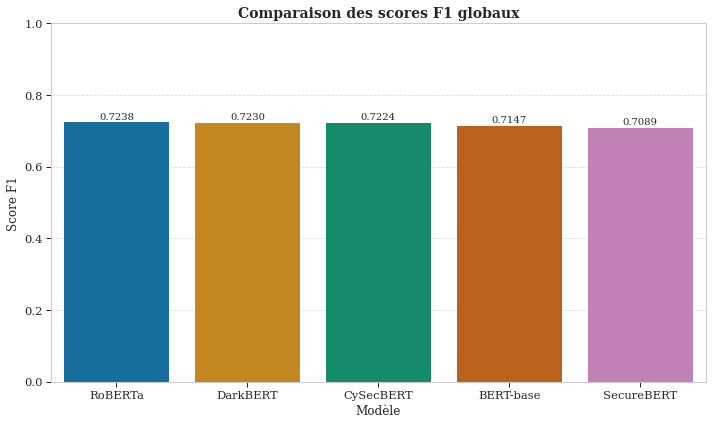


2. Affichage du graphique de comparaison des scores F1 par source...


<ipython-input-3-8dece30c9555>:165: UserWarning: 
The palette list has fewer values (4) than needed (25) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(


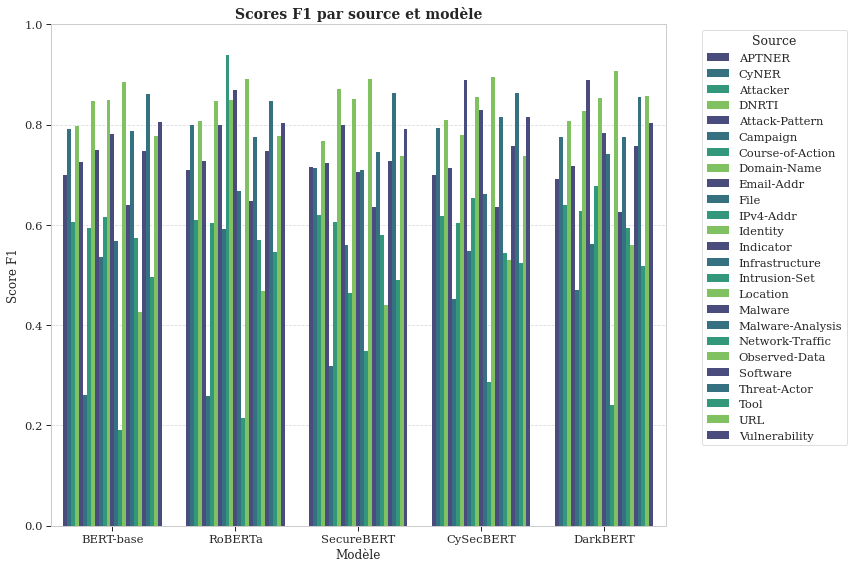


3. Affichage du graphique en groupes de barres...


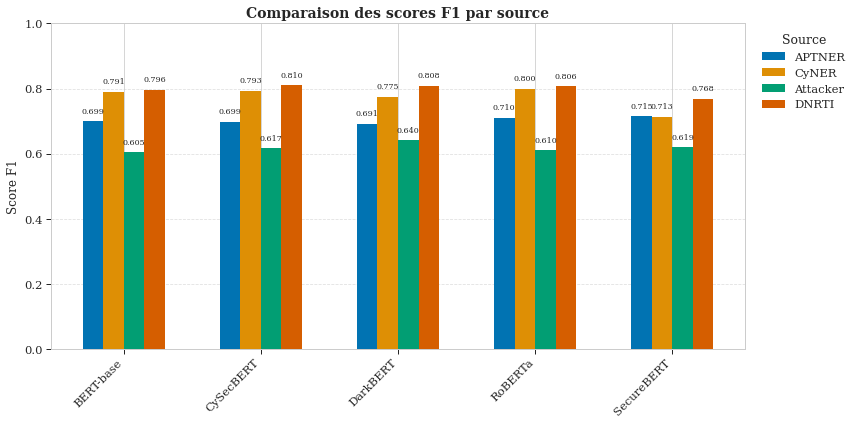


4. Affichage de la carte thermique des performances par entité...


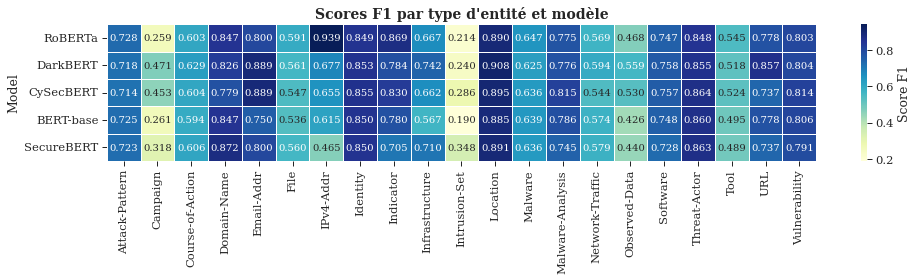


5. Affichage du graphique radar des performances par source...


ValueError: x and y must have same first dimension, but have shapes (5,) and (26,)

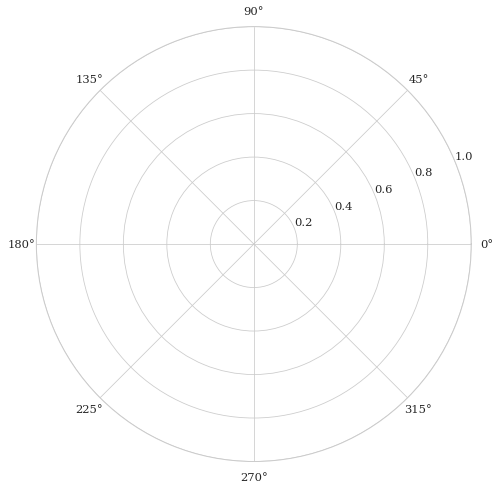

In [4]:
main()